# NYKAA DATASET EDA (Makeup, Health Care & Baby Care)

## Business Understanding:

### Project Description:

- In this project, I have collected product data from Nykaa and performed Data Cleaning and Exploratory Data Analysis (EDA).
- The purpose is to analyze Makeup, Health Care, and Baby Care products and understand customer popularity using `Rating Count`.


 ### Problem Statement :
 
Given Problem Statement :

`“Analysis of Makeup products, Health Care products and Baby Care products.” `

## Target Variable & Features:

### Target Variable:
I am considering **Rating** as the target variable because it represents the **rating count**, which indicates the **popularity of a product**.
Higher rating count means more customer engagement and trust in that product.


### Why Rating Count?

- Rating count represents how many customers have rated the product.

- Higher rating count means:

  + Higher customer engagement

  + Higher trust

  + Higher popularity

### Independent Features (for analysis with Rating):
- Category (Makeup / Health Care / Baby Care)
- Brand Name
- MRP
- Selling Price
- Discount
- Tag (BESTSELLER, AD, None etc.)

These features will help me analyze and compare the three categories based on pricing, discounts, brand performance and popularity.


In [1]:
import pandas as pd                 #importing pandas library
import numpy as np                  #importing numpy library
import matplotlib.pyplot as plt     # importing matplotlib
import seaborn as sns               # importing seaborn

- Pandas is used for data loading and exploration
- NumPy is used for numerical operations
- Matplotlib and Seaborn are used for visualization to support analysis.

In [2]:
#Loading dataset:
df = pd.read_csv("/Users/mohammadimran/nykaa_final.csv")
df

,Category,Product Name,MRP,Selling Price,Discount,Tag,Rating,Brand Name
0,Makeup,Garnier Skin Naturals Micellar OilInfused Clea...,₹499,₹324,35%,AD,( 268953 ),Garnier Skin
1,Makeup,Nykaa Matte To Last Transferproof Liquid Lips...,₹749,₹487,35%,BESTSELLER,( 2388915 ),Nykaa
2,Makeup,Nykaa Cosmetics So Creme Creamy Matte Lipstick,₹329,₹214,35%,BESTSELLER,( 4027582 ),Nykaa Cosmetics
3,Makeup,Swiss Beauty Bold Matt Lip Liner Pencil Longla...,₹429,₹69,10%,BESTSELLER,( 263353 ),Swiss Beauty
4,Makeup,Swiss Beauty Real MakeUp Base Highlighting Pri...,₹1099,₹386,10%,BESTSELLER,( 109953 ),Swiss Beauty
...,...,...,...,...,...,...,...,...
4595,Wellness,"Sirona Premium Disposable Maternity Breast Pads,",₹650,₹149,7%,NaN,( 115367 ),Sirona Premium
4596,Wellness,"Palmer's Cocoa Butter Nursing Butter, For",₹299,₹450,21%,NaN,( 279 ),Palmer's Cocoa
4597,Wellness,Max Care Virgin Coconut Oil -,₹800,₹605,25%,NaN,( 77 ),Max Care
4598,Wellness,Sirona Pregrx Midstream One Step Urine,NaN,₹236,NaN,NaN,NaN,Sirona Pregrx


In [3]:
df.shape # to see how many rows and how many columns are their in dataset

(4600, 8)

### Observations:

- The dataset contains 4600 rows and 8 columns.
- Each row represents a product available on Nykaa platform.

In [4]:
df.info()  # used to inspect column data types and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       4600 non-null   object
 1   Product Name   4600 non-null   object
 2   MRP            3702 non-null   object
 3   Selling Price  4600 non-null   object
 4   Discount       3702 non-null   object
 5   Tag            4000 non-null   object
 6   Rating         4580 non-null   object
 7   Brand Name     4600 non-null   object
dtypes: object(8)
memory usage: 287.6+ KB


### Observation:

+ Here I checked column names and datatypes.
+ All columns are object type because they contain symbols like ₹, %, and brackets which need to be cleaned.
+  We can also see missing values in:

      + MRP
  
      + Discount and
  
      +  Rating

## Column Renaming (For Better Understanding):

In [5]:
# Changing Rating column name to Rating Count:
df.rename(columns={"Rating": "Rating Count"}, inplace=True)
# Changing Discount to Discount%:
df.rename(columns={"Discount": "Discount%"}, inplace=True)

In [6]:
df.columns

Index(['Category', 'Product Name', 'MRP', 'Selling Price', 'Discount%', 'Tag',
       'Rating Count', 'Brand Name'],
      dtype='object')

### Observation:

- I renamed **Rating** to **Rating Count** because this column represents the **number of ratings received by a product**, not the star rating out of 5.
- I renamed **Discount** to **Discount%** because the values are in **percentage format**, so it becomes easier to understand during analysis and visualization.


In [7]:
df.dtypes # checkiing data types

Category         object
Product Name     object
MRP              object
Selling Price    object
Discount%        object
Tag              object
Rating Count     object
Brand Name       object
dtype: object

## Removing Symbols and Converting Data Types

In [8]:
# Removing special characters and symbols:
df["MRP"] = df["MRP"].astype(str).str.replace("₹", "").str.replace(",", "")
df["Selling Price"] = df["Selling Price"].astype(str).str.replace("₹", "").str.replace(",", "")

df["Discount%"] = df["Discount%"].astype(str).str.replace("%", "")

df["Rating Count"] = df["Rating Count"].astype(str).str.replace("(", "").str.replace(")", "").str.replace(" ", "")

In [9]:
# Changing MRP,Selling Price,Discount%,Rating Count(k) into numerical columns:

df["MRP"] = pd.to_numeric(df["MRP"], errors="coerce")
df["Selling Price"] = pd.to_numeric(df["Selling Price"], errors="coerce")
df["Discount%"] = pd.to_numeric(df["Discount%"], errors="coerce")
df["Rating Count"] = pd.to_numeric(df["Rating Count"].astype(str).str.strip(), errors="coerce")

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Category       4600 non-null   object 
 1   Product Name   4600 non-null   object 
 2   MRP            3702 non-null   float64
 3   Selling Price  4600 non-null   int64  
 4   Discount%      3702 non-null   float64
 5   Tag            4000 non-null   object 
 6   Rating Count   4580 non-null   float64
 7   Brand Name     4600 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 287.6+ KB


#### Observation:
- Here, we can observe that MRP,Discount% and Rating Count showing `Float64`.
- They have NaN in them.
- Any wrong/blank value becomes NaN.
- And pandas stores columns with NaN as float by default.

In [13]:
#  Filling missing MRP values using Selling Price
df["MRP"] = df["MRP"].fillna(df["Selling Price"])
print("MRP null values:", df["MRP"].isnull().sum())

# Filling missing Discount% values with 0
df["Discount%"] = df["Discount%"].fillna(0)
print("Discount% null values:", df["Discount%"].isnull().sum())

# Removing rows where Rating Count is missing (target variable)
df = df[df["Rating Count"].notna()]
print("Rating Count null values:", df["Rating Count"].isnull().sum())

# Filling missing Tag values with "No Tag"
df["Tag"] = df["Tag"].fillna("No Tag")
print("Tag null values:", df["Tag"].isnull().sum())

MRP null values: 0
Discount% null values: 0
Rating Count null values: 0
Tag null values: 0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4580 entries, 0 to 4597
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Category       4580 non-null   object 
 1   Product Name   4580 non-null   object 
 2   MRP            4580 non-null   float64
 3   Selling Price  4580 non-null   int64  
 4   Discount%      4580 non-null   float64
 5   Tag            4580 non-null   object 
 6   Rating Count   4580 non-null   float64
 7   Brand Name     4580 non-null   object 
dtypes: float64(3), int64(1), object(4)
memory usage: 322.0+ KB


## Handling Missing Values (Assumptions)

- If **MRP** is missing, I assumed the product MRP is same as **Selling Price**.
- If **Discount%** is missing, I assumed there is **no discount**, so I filled it with **0**.
- If **Rating Count** is missing, I removed those rows because **Rating Count is my target variable** and I cannot assume its value.
- After removing rows total rows are `4580`


In [15]:
df.head() 

,Category,Product Name,MRP,Selling Price,Discount%,Tag,Rating Count,Brand Name
0,Makeup,Garnier Skin Naturals Micellar OilInfused Clea...,499.0,324,35.0,AD,268953.0,Garnier Skin
1,Makeup,Nykaa Matte To Last Transferproof Liquid Lips...,749.0,487,35.0,BESTSELLER,2388915.0,Nykaa
2,Makeup,Nykaa Cosmetics So Creme Creamy Matte Lipstick,329.0,214,35.0,BESTSELLER,4027582.0,Nykaa Cosmetics
3,Makeup,Swiss Beauty Bold Matt Lip Liner Pencil Longla...,429.0,69,10.0,BESTSELLER,263353.0,Swiss Beauty
4,Makeup,Swiss Beauty Real MakeUp Base Highlighting Pri...,1099.0,386,10.0,BESTSELLER,109953.0,Swiss Beauty


In [16]:
# Convert only if there are no NaN values
if df["MRP"].isna().sum() == 0:
    df["MRP"] = df["MRP"].astype(int)

if df["Discount%"].isna().sum() == 0:
    df["Discount%"] = df["Discount%"].astype(int)

if df["Rating Count"].isna().sum() == 0:
    df["Rating Count"] = df["Rating Count"].astype(int)

# Check datatypes
df.dtypes

Category         object
Product Name     object
MRP               int64
Selling Price     int64
Discount%         int64
Tag              object
Rating Count      int64
Brand Name       object
dtype: object

### Converting Float64 to Integer:

After handling missing values, the numerical columns were still showing as float64 with decimal values like 499.0 and 35.0.  
These values represent complete numbers (rupees,percentage and ratings count), so I converted them into integer type to:

-  Remove unnecessary decimal points (e.g., 499.0 → 499)
-  Improve readability of the dataset
-  Make the data look clean and consistent for EDA and reporting


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4580 entries, 0 to 4597
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Category       4580 non-null   object
 1   Product Name   4580 non-null   object
 2   MRP            4580 non-null   int64 
 3   Selling Price  4580 non-null   int64 
 4   Discount%      4580 non-null   int64 
 5   Tag            4580 non-null   object
 6   Rating Count   4580 non-null   int64 
 7   Brand Name     4580 non-null   object
dtypes: int64(4), object(4)
memory usage: 322.0+ KB


## Data Types After Cleaning:

Now my dataset has:

- **4 object columns** (text): Category, Product Name, Brand Name, Tag
- **4 int columns** (numbers): MRP, Selling Price, Discount%,Rating Count

So my data is clean and ready for EDA.


In [18]:
df.head()

,Category,Product Name,MRP,Selling Price,Discount%,Tag,Rating Count,Brand Name
0,Makeup,Garnier Skin Naturals Micellar OilInfused Clea...,499,324,35,AD,268953,Garnier Skin
1,Makeup,Nykaa Matte To Last Transferproof Liquid Lips...,749,487,35,BESTSELLER,2388915,Nykaa
2,Makeup,Nykaa Cosmetics So Creme Creamy Matte Lipstick,329,214,35,BESTSELLER,4027582,Nykaa Cosmetics
3,Makeup,Swiss Beauty Bold Matt Lip Liner Pencil Longla...,429,69,10,BESTSELLER,263353,Swiss Beauty
4,Makeup,Swiss Beauty Real MakeUp Base Highlighting Pri...,1099,386,10,BESTSELLER,109953,Swiss Beauty


###  Converting `Rating Count` into K / M Format (Separate Column):

For better readability in my dataset, I kept the original **`Rating Count`** column (numeric) and created a new column **`Rating Count (K/M)`** to display the values in **K (Thousands)** and **M (Millions)** format.

 Example:
- 850 → 850  
- 12,000 → 12.0K  
- 2,500,000 → 2.5M

In [19]:
def format_k_m(x):
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{x/1_000:.1f}K"
    else:
        return str(int(x))

df["Rating Count (K/M)"] = df["Rating Count"].apply(format_k_m)

In [20]:
df.head()

,Category,Product Name,MRP,Selling Price,Discount%,Tag,Rating Count,Brand Name,Rating Count (K/M)
0,Makeup,Garnier Skin Naturals Micellar OilInfused Clea...,499,324,35,AD,268953,Garnier Skin,269.0K
1,Makeup,Nykaa Matte To Last Transferproof Liquid Lips...,749,487,35,BESTSELLER,2388915,Nykaa,2.4M
2,Makeup,Nykaa Cosmetics So Creme Creamy Matte Lipstick,329,214,35,BESTSELLER,4027582,Nykaa Cosmetics,4.0M
3,Makeup,Swiss Beauty Bold Matt Lip Liner Pencil Longla...,429,69,10,BESTSELLER,263353,Swiss Beauty,263.4K
4,Makeup,Swiss Beauty Real MakeUp Base Highlighting Pri...,1099,386,10,BESTSELLER,109953,Swiss Beauty,110.0K


###  Removing Unimportant Words from `Product Name`

- To clean the **Product Name** column, I removed common **unimportant words** like:
 `with, for, and, the, of, in, by, pack, combo, set, ml, gm`

- This helps in making the product names short and more meaningful for analysis using regex 


In [21]:
import re

stop_words = [
    "with", "for", "and", "the", "of", "in", "by",
    "pack", "combo", "set", "ml", "gm", "g", "pcs"
]

pattern = r"\b(" + "|".join(stop_words) + r")\b"

df["Product Name"] = df["Product Name"].astype(str).str.lower()
df["Product Name"] = df["Product Name"].str.replace(pattern, "", regex=True)

# Remove extra spaces after deletion
df["Product Name"] = df["Product Name"].str.replace(r"\s+", " ", regex=True).str.strip()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4580 entries, 0 to 4597
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Category            4580 non-null   object
 1   Product Name        4580 non-null   object
 2   MRP                 4580 non-null   int64 
 3   Selling Price       4580 non-null   int64 
 4   Discount%           4580 non-null   int64 
 5   Tag                 4580 non-null   object
 6   Rating Count        4580 non-null   int64 
 7   Brand Name          4580 non-null   object
 8   Rating Count (K/M)  4580 non-null   object
dtypes: int64(4), object(5)
memory usage: 357.8+ KB


In [23]:
# Step 1: clean symbols, brackets, commas, extra spaces
df["Brand Name"] = (
    df["Brand Name"]
    .astype(str)
    .str.replace(r"[\[\]\(\)\{\},'\"`]", "", regex=True)   # remove brackets, commas, quotes
    .str.replace(r"\s+", " ", regex=True)                 # remove extra spaces
    .str.strip()                                          # clean start/end spaces
)

# Step 2: make common brand name (same first word => one brand)
df["Brand Name"] = df["Brand Name"].str.split().str[0]

# Step 3: fix empty / 'nan' values after cleaning
df["Brand Name"] = df["Brand Name"].replace(["", "nan", "None"], "Unknown")

In [24]:
print("Total Rows =", len(df))
print("Unique Brands =", df["Brand Name"].nunique())
print(sorted(df["Brand Name"].unique())[:50])  # showing first 50 brands

Total Rows = 4580
Unique Brands = 143
['Aravi', 'Auric', 'Aveeno', 'BABY', 'Baby', 'Baidyanath', 'Bare', 'Be', 'Beautiliss', 'Beautywise', 'Bella', 'Bio', 'Bioderma', 'Biotique', 'Bloom', 'Bonayu', 'Botanical', 'Brillare', 'Bronson', 'Carbamide', 'Cetaphil', 'Charlotte', 'Chicco', 'Chicnutrix', 'Colgate', 'Cos-IQ', 'Cottsberry', 'Cureveda', 'Daily', 'Deve', 'Dove', 'Dr.', 'Fast&Up', 'Feel', 'Fixderma', 'Flicka', 'Forest', 'GUBB', 'Garnier', 'Glutone', 'Glutone-Hydra', 'Glutone1000', 'Gorgio', 'Gritzo', 'HealthKart', 'Healthkart', 'HealthyHey', 'Himalaya', 'INJA', 'ISDIN']


In [25]:
print("Total Rows =", len(df))
print("Unique Brands =", df["Brand Name"].nunique())

Total Rows = 4580
Unique Brands = 143


## Explanation:

In my dataset, I found that some brand names were written in different ways but they mean the same brand.
For example: Baby and baby are same, Glutone Hydra and Glutone1000 are also Glutone, and HealthKart and Healthkart are the same.

So, I cleaned the Brand Name column by removing extra spaces, making all names in proper format, and merging similar brand names into one common name.
This made the Brand Name column clean and consistent for further EDA.

### Checking duplicates and removing it if necessary:

In [26]:
df.duplicated().sum()

np.int64(3983)

In [27]:
df[df.duplicated()].head(10)

,Category,Product Name,MRP,Selling Price,Discount%,Tag,Rating Count,Brand Name,Rating Count (K/M)
20,Makeup,garnier skin naturals micellar oilinfused clea...,499,324,35,AD,268953,Garnier,269.0K
21,Makeup,nykaa matte to last transferproof liquid lipstick,749,487,35,BESTSELLER,2388915,Nykaa,2.4M
22,Makeup,nykaa cosmetics so creme creamy matte lipstick,329,214,35,BESTSELLER,4027582,Nykaa,4.0M
23,Makeup,swiss beauty bold matt lip liner pencil longla...,429,69,10,BESTSELLER,263353,Swiss,263.4K
24,Makeup,swiss beauty real makeup base highlighting pri...,1099,386,10,BESTSELLER,109953,Swiss,110.0K
25,Makeup,kay beauty hydra creme lipstick,749,989,40,AD,5299,Kay,5.3K
26,Makeup,maybelline new york super stay matte ink liqui...,849,449,35,BESTSELLER,3871779,Maybelline,3.9M
27,Makeup,maybelline new york super stay vinyl ink liqui...,799,552,40,BESTSELLER,47579,Maybelline,47.6K
28,Makeup,kay beauty soft matte pressed powder 120p light,1350,1199,25,BESTSELLER,104,Kay,104
29,Makeup,maybelline new york instant age rewind eraser ...,799,479,5,BESTSELLER,934024,Maybelline,934.0K


In [28]:
df = df.drop_duplicates(keep="first").reset_index(drop=True)

In [29]:
print("Duplicates after:", df.duplicated().sum())
print("Total rows now:", len(df))

Duplicates after: 0
Total rows now: 597


## Removing Exact Duplicate Rows:

After checking my dataset, I found that some rows were repeated exactly the same.  
So, I first calculated the number of duplicate rows using `duplicated().sum()`.

Then, I removed only the exact duplicate rows where all column values were identical using `drop_duplicates()` (this does not remove rows with different prices or categories).  

Finally, I checked again to confirm that all exact duplicate rows were removed and the dataset is clean for further analysis.


In [30]:
df.info() #checking total rows and columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Category            597 non-null    object
 1   Product Name        597 non-null    object
 2   MRP                 597 non-null    int64 
 3   Selling Price       597 non-null    int64 
 4   Discount%           597 non-null    int64 
 5   Tag                 597 non-null    object
 6   Rating Count        597 non-null    int64 
 7   Brand Name          597 non-null    object
 8   Rating Count (K/M)  597 non-null    object
dtypes: int64(4), object(5)
memory usage: 42.1+ KB


In [34]:
df.to_csv("nykaa_cleaned.csv", index=False)  # Saving  cleaned dataframe to csv

In [38]:
check_df = pd.read_csv("nykaa_cleaned.csv") #checking if it saved or not
check_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Category            597 non-null    object
 1   Product Name        597 non-null    object
 2   MRP                 597 non-null    int64 
 3   Selling Price       597 non-null    int64 
 4   Discount%           597 non-null    int64 
 5   Tag                 597 non-null    object
 6   Rating Count        597 non-null    int64 
 7   Brand Name          597 non-null    object
 8   Rating Count (K/M)  597 non-null    object
dtypes: int64(4), object(5)
memory usage: 42.1+ KB


## Overall Data Cleaning Summary:

In this dataset, I performed data cleaning to make the data accurate and consistent for further analysis.  
First, I handled missing values by filling missing **MRP** values using **Selling Price**, and filling missing **Discount%** values with **0**.  
I also filled missing values in the **Tag** column with **No Tag** to avoid null entries.

Since **Rating Count** is my target variable, I removed the rows where **Rating Count** was missing.  
After that, I cleaned and standardized the **Brand Name** column by fixing inconsistencies and merging similar brand name variations into one common format.

Finally, I checked duplicate rows and removed only the exact duplicates where all column values were identical.  
These steps helped me improve the dataset quality and made it ready for EDA and insights generation.


## Final Dataset Shape:

After completing the data cleaning process (handling missing values, fixing brand names, and removing exact duplicate rows), my dataset became more clean and consistent.

Now my final cleaned dataset contains **597 rows** and **9 columns**, which is ready for further EDA and analysis.


## Summary Statistics:

In [39]:
df.describe()

,MRP,Selling Price,Discount%,Rating Count
count,597.000000,597.000000,597.000000,5.970000e+02
mean,1101.304858,949.398660,17.090452,2.382571e+04
std,1389.034531,1124.104562,13.571407,2.525937e+05
min,49.000000,44.000000,0.000000,1.000000e+00
25%,399.000000,342.000000,7.000000,3.200000e+01
50%,695.000000,604.000000,15.000000,2.070000e+02
75%,1360.000000,1196.000000,25.000000,9.360000e+02
max,16469.000000,15199.000000,70.000000,4.027582e+06


## Observations (Summary Statistics):

- The dataset contains 597 products after cleaning.
- MRP ranges from 49 to 16469, which shows there are both **budget and premium products**.
- Selling Price ranges from 44 to 15199, meaning some products are heavily discounted.
- Discount% ranges from 0% to 70%, so discounts are present but not extreme beyond 70%.
- Rating Count is `highly right-skewed` because the minimum value is 1, the median is 207, but the maximum goes up to 4,027,582.
- This indicates that a `few products are extremely popular` and behave like outliers, while most products have low to moderate rating counts.

## Checking Outliers:(Using Graphs and Insights)

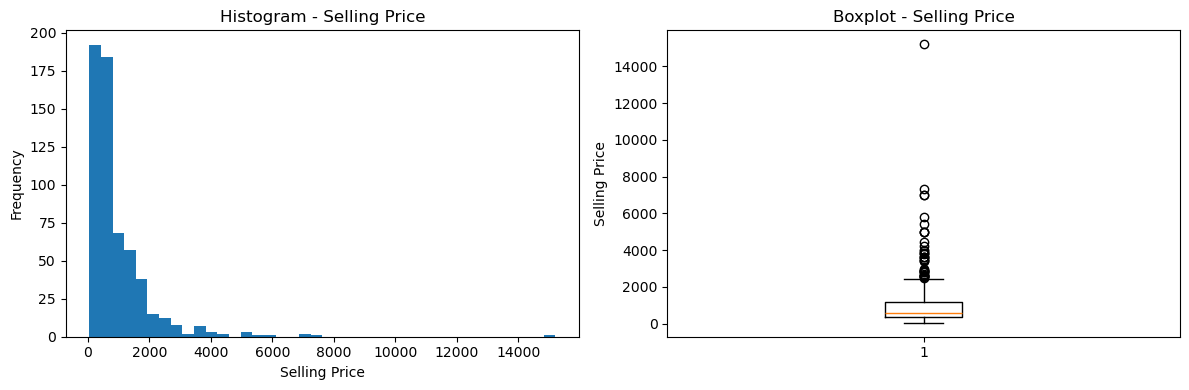

In [40]:
# checking outliers in selling price:

plt.figure(figsize=(12,4))

# Histogram (Left)
plt.subplot(1, 2, 1)
plt.hist(df["Selling Price"], bins=40)
plt.title("Histogram - Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

#  Boxplot (Right)
plt.subplot(1, 2, 2)
plt.boxplot(df["Selling Price"])
plt.title("Boxplot - Selling Price")
plt.ylabel("Selling Price")

plt.tight_layout()
plt.show()

### Insights:
- The selling price distribution is right-skewed, with most products priced at the lower range and very few high-priced items.
- The boxplot shows the presence of several high-value outliers, indicating premium products with significantly higher prices.

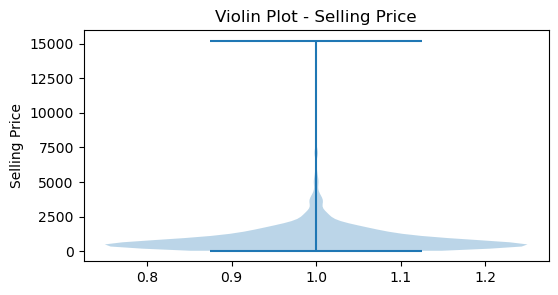

In [41]:
## Violin plot for Selling Price
plt.figure(figsize=(6,3))
plt.violinplot(df["Selling Price"])
plt.title("Violin Plot - Selling Price")
plt.ylabel("Selling Price")
plt.show()

### Insight:
- The violin plot shows a high concentration of products in the lower price range, indicating most items are affordably priced.
- The long and thin upper tail represents fewer high-priced products, confirming the presence of price outliers.

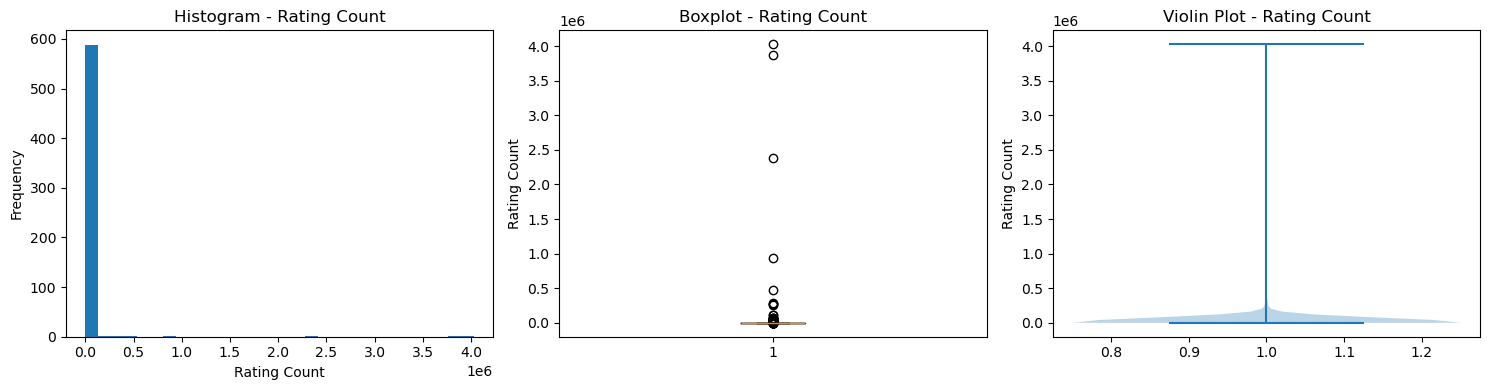

In [42]:
# Checking outliers in Rating count:
plt.figure(figsize=(15,4))

#  Histogram
plt.subplot(1, 3, 1)
plt.hist(df["Rating Count"], bins=30)
plt.title("Histogram - Rating Count")
plt.xlabel("Rating Count")
plt.ylabel("Frequency")

#  Boxplot
plt.subplot(1, 3, 2)
plt.boxplot(df["Rating Count"])
plt.title("Boxplot - Rating Count")
plt.ylabel("Rating Count")

#  Violin Plot
plt.subplot(1, 3, 3)
plt.violinplot(df["Rating Count"])
plt.title("Violin Plot - Rating Count")
plt.ylabel("Rating Count")

plt.tight_layout()
plt.show()

### Insights:
- The rating count distribution is highly right-skewed, where most products have very low rating counts.
- The boxplot and violin plot show extreme high-value outliers, indicating that only a few products receive a very large number of ratings


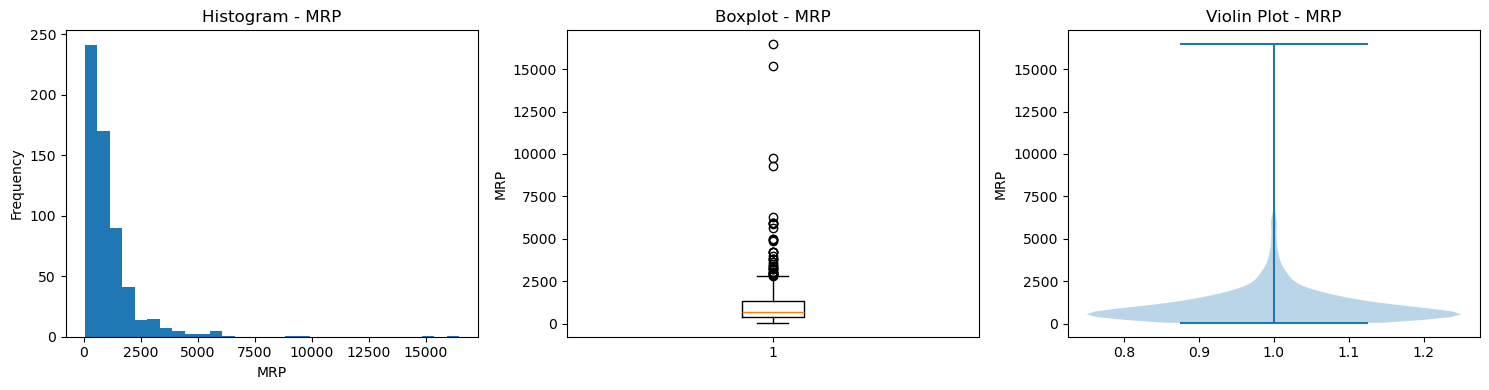

In [43]:
# checking outliers in MRP:
plt.figure(figsize=(15,4))

#  Histogram
plt.subplot(1, 3, 1)
plt.hist(df["MRP"], bins=30)
plt.title("Histogram - MRP")
plt.xlabel("MRP")
plt.ylabel("Frequency")

#  Boxplot
plt.subplot(1, 3, 2)
plt.boxplot(df["MRP"])
plt.title("Boxplot - MRP")
plt.ylabel("MRP")

#  Violin Plot
plt.subplot(1, 3, 3)
plt.violinplot(df["MRP"])
plt.title("Violin Plot - MRP")
plt.ylabel("MRP")

plt.tight_layout()
plt.show()


### Insights:
- Most products fall in the low to mid MRP range, showing that the majority of items are affordable.

- The distribution is right-skewed, with a small number of products having very high MRPs.

- The presence of high-MRP outliers suggests premium or luxury products influencing the overall spread.


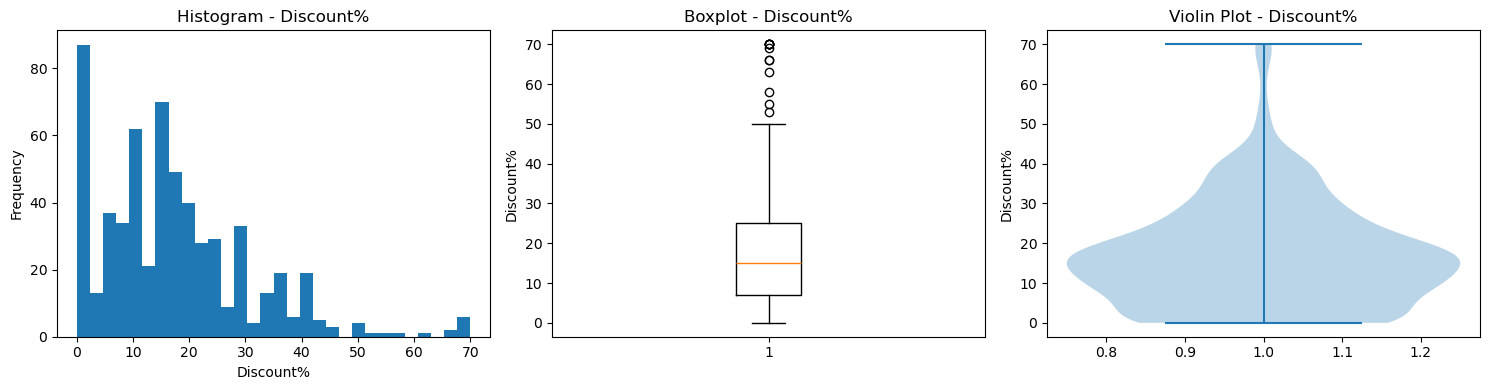

In [44]:
# Checking Outliers in Discount%:
plt.figure(figsize=(15,4))

#  Histogram – Discount%
plt.subplot(1, 3, 1)
plt.hist(df["Discount%"], bins=30)
plt.title("Histogram - Discount%")
plt.xlabel("Discount%")
plt.ylabel("Frequency")

#  Boxplot – Discount%
plt.subplot(1, 3, 2)
plt.boxplot(df["Discount%"])
plt.title("Boxplot - Discount%")
plt.ylabel("Discount%")

#  Violin Plot – Discount%
plt.subplot(1, 3, 3)
plt.violinplot(df["Discount%"])
plt.title("Violin Plot - Discount%")
plt.ylabel("Discount%")

plt.tight_layout()
plt.show()

#### Insights:
- Most products have low to moderate discounts, mainly between 0% and 30%.
- The distribution is right-skewed, showing that higher discount values are less common.
- Only a small number of products offer very high discounts (above ~40%).
- The boxplot indicates the presence of high-discount outliers, which are rare.
- Overall, the data suggests that products are generally lightly discounted rather than heavily discounted.

### Outliers Treatment Decision:

The objective of this analysis is to study Makeup, Health Care, and Baby Care products and understand customer popularity using Rating Count.

Outliers were identified using boxplots, histograms, and violin plots for numerical variables such as Rating Count, MRP, Selling Price, and Discount%.

However, outlier treatment was not applied because these extreme values represent valid business scenarios.
High values in Rating Count indicate highly popular products, while extreme values in MRP and Selling Price correspond to premium or luxury items.
Similarly, higher Discount% values generally occur during promotional events or seasonal sales.

Removing or capping these values could distort customer popularity and pricing patterns.
Therefore, outliers were retained to preserve the real-world characteristics of the Nykaa dataset.

## Univariate Analysis:

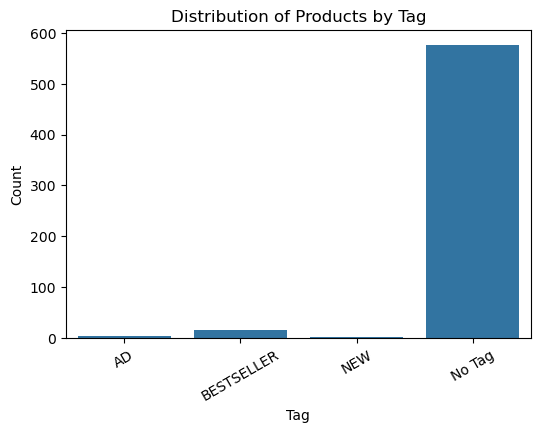

In [45]:
# Tag:
plt.figure(figsize=(6,4))
sns.countplot(x='Tag', data=df)

plt.xlabel('Tag')
plt.ylabel('Count')
plt.title('Distribution of Products by Tag')
plt.xticks(rotation=30)
plt.show()

### Insights:
- The dataset is heavily dominated by products with **No Tag**, indicating that most items are not assigned any promotional label.
- Only a small number of products are marked as **Bestseller**, **Ad**, or **New**, showing selective use of tags.
- The tag distribution is highly **imbalanced**, which should be considered while performing tag-based analysis.


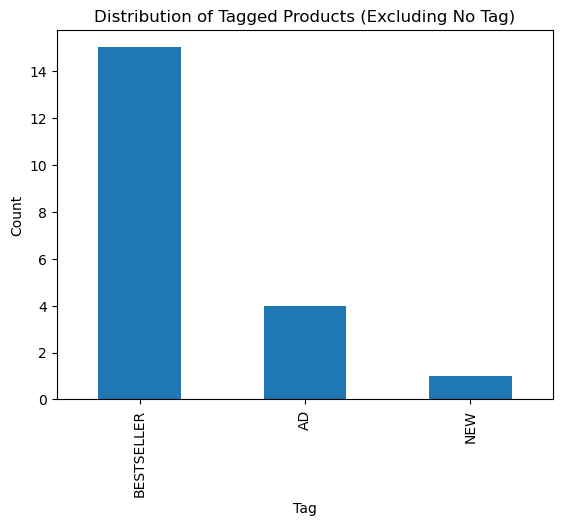

In [46]:
# After removing No Tag:
df[df['Tag'] != 'No Tag']['Tag'].value_counts().plot(kind='bar')
plt.title('Distribution of Tagged Products (Excluding No Tag)')
plt.xlabel('Tag')
plt.ylabel('Count')
plt.show()

### Insight:
- After excluding "No Tag", **Bestseller** appears as the most common promotional tag, followed by **Ad** and **New**.

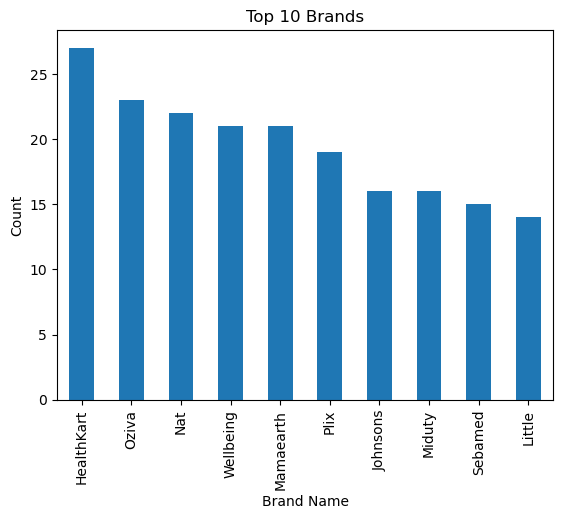

In [47]:
# Analysis on Brand Name:
df['Brand Name'].value_counts().head(10).plot(kind='bar')
plt.xlabel('Brand Name')
plt.ylabel('Count')
plt.title('Top 10 Brands')
plt.show()

### Insights:

- HealthKart has the highest product count among the top 10 brands, indicating strong representation in the dataset.

- Oziva, Nat Habit, and Wellbeing follow closely, showing competitive product availability across these brands.

- Mamaearth and Plix fall in the mid-range with a moderate number of listed products.

- Brands like Johnson’s, Miduty, Sebamed, and Little have comparatively fewer products, indicating a smaller catalog size.

- Overall, the distribution shows a gradual decline in product count across brands, with no extreme dominance except the leading brand

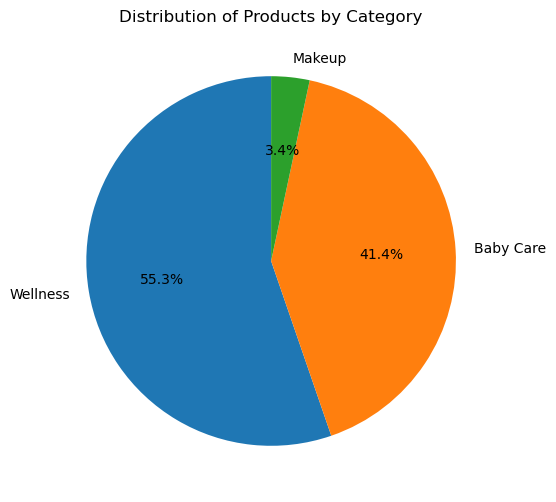

In [48]:
# Category:
df['Category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6),
    startangle=90
)

plt.title('Distribution of Products by Category')
plt.ylabel('')
plt.show()

### Insights:

- Wellness is the dominant category, contributing around 55.3% of the total products in the dataset.

- Baby Care forms a significant portion with about 41.4%, indicating strong representation of baby-related products.

- Makeup has a very small share (around 3.4%), suggesting limited product availability compared to other categories.


## Bivariate Analysis:

In [49]:
# Average Rating Count by Category
df.groupby('Category')['Rating Count'].mean().reset_index()

,Category,Rating Count
0,Baby Care,3927.88664
1,Makeup,632725.65000
2,Wellness,1815.90000


#### Insights:
- Makeup products have the highest average rating count, showing very strong customer engagement.
- Baby Care has a moderate average rating count, indicating steady and consistent customer interest.
- Wellness shows the lowest average rating count, suggesting comparatively lower customer interaction or newer listings.

In [50]:
# Average Selling Price by Category
df.groupby('Category')['Selling Price'].mean().reset_index()

,Category,Selling Price
0,Baby Care,611.125506
1,Makeup,934.900000
2,Wellness,1203.469697


#### Insights:
- Wellness products have the highest average selling price, indicating premium or higher-value items.
- Makeup falls in the mid-price range, balancing affordability and premium offerings.
- Baby Care has the lowest average selling price, suggesting more budget-friendly products.

In [51]:
#Rating Count by Tag
pd.pivot_table(df, 'Rating Count', index='Tag', aggfunc='mean')

,Rating Count
Tag,
AD,189884.750000
BESTSELLER,792935.133333
NEW,947.000000
No Tag,2719.991334


#### Insights:
- Bestseller products have the highest average rating count, showing very strong popularity and customer trust.
- Ad tagged products receive high engagement, but much lower than bestsellers.
- New and No Tag products have very low rating counts, indicating limited visibility or fewer purchases.

#### Numerical vs Numerical:

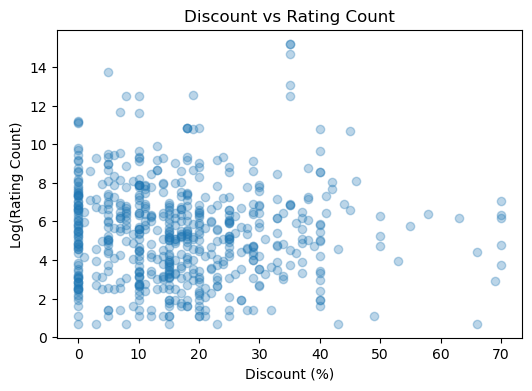

In [52]:
#(Discount% vs Rating count)
plt.figure(figsize=(6,4))
plt.scatter(df['Discount%'], np.log1p(df['Rating Count']), alpha=0.3)
plt.xlabel('Discount (%)')
plt.ylabel('Log(Rating Count)')
plt.title('Discount vs Rating Count')
plt.show()

#### Insight:

- Products with low to medium discounts (0–30%) receive most of the ratings.
- Higher discounts do not always lead to higher rating counts, showing no strong relationship between discount and popularity.

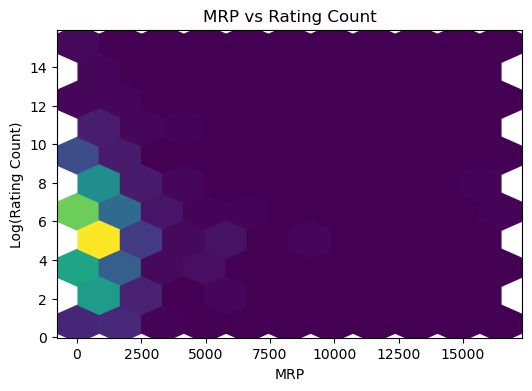

In [53]:
#MRP vs Rating count:
plt.figure(figsize=(6,4))
plt.hexbin(df['MRP'], np.log1p(df['Rating Count']), gridsize=10)
plt.xlabel('MRP')
plt.ylabel('Log(Rating Count)')
plt.title('MRP vs Rating Count')
plt.show()

### Insight:
- Most products with higher rating counts are in the lower MRP range, showing that affordable products get more reviews.

- As MRP increases, rating count generally decreases, indicating expensive products receive fewer ratings.

#### Categorical vs Categorical:

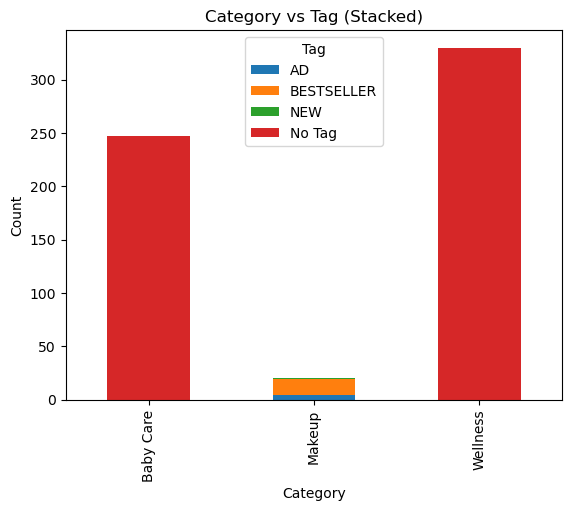

In [54]:
# Category vs Tag:
pd.crosstab(df['Category'], df['Tag']).plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Category vs Tag (Stacked)')
plt.show()

#### Insights:
- Across all categories, most products fall under “No Tag”, showing that tagging is used for only a small number of products.
- Makeup has relatively more Bestseller and Ad tags compared to Baby Care and Wellness, where tagged products are very limited.

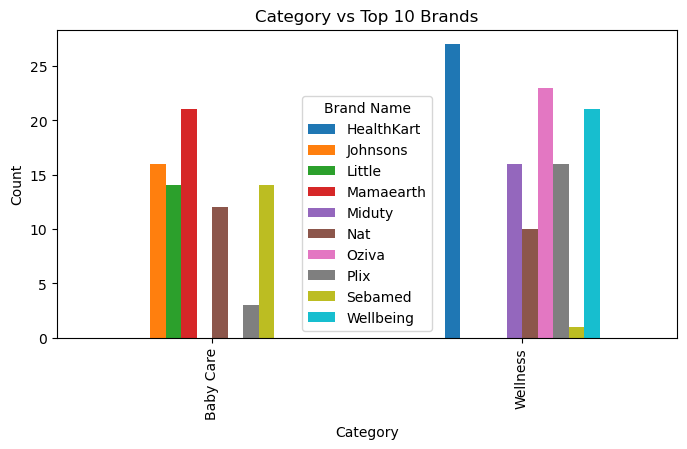

In [55]:
# category vs Brand:
top_brands = df['Brand Name'].value_counts().head(10).index

pd.crosstab(
    df['Category'],
    df[df['Brand Name'].isin(top_brands)]['Brand Name']
).plot(kind='bar', figsize=(8,4))

plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Category vs Top 10 Brands')
plt.show()

#### Insights:
- Baby Care products are mainly dominated by brands like Mamaearth, Johnson’s, Little, and Sebamed, showing strong brand presence in this category.

- Wellness products are largely led by HealthKart, Oziva, Wellbeing, and Plix, indicating that these brands focus more on wellness-related items.

#### Categorical vs Numerical:

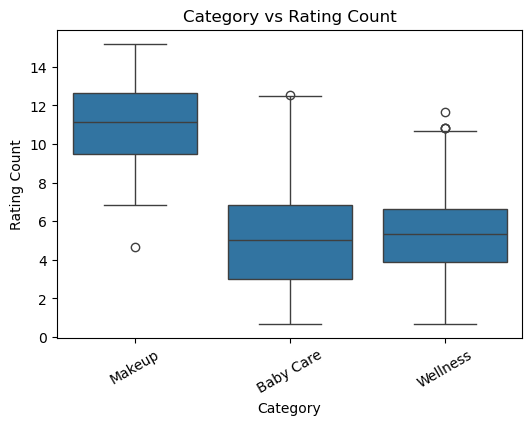

In [56]:
# category vs Rating Count:
plt.figure(figsize=(6,4))
sns.boxplot(x='Category', y=np.log1p(df['Rating Count']), data=df)
plt.title('Category vs Rating Count')
plt.xticks(rotation=30)
plt.show()

#### Insights:

Makeup products generally receive higher rating counts compared to Baby Care and Wellness categories.

Baby Care and Wellness show similar rating patterns, with moderate ratings and some outliers, indicating a few highly popular products.

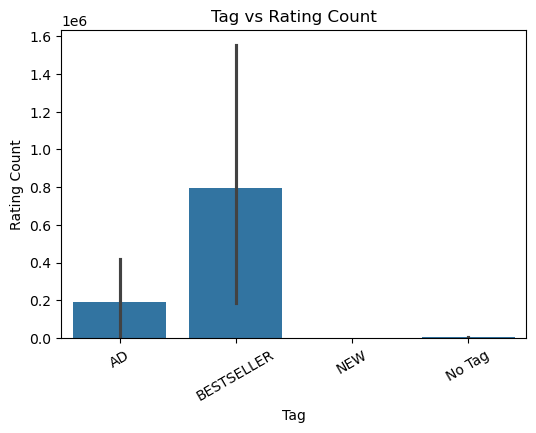

In [57]:
# Tag vs Rating Count:
plt.figure(figsize=(6,4))
sns.barplot(x='Tag', y='Rating Count', data=df)
plt.title('Tag vs Rating Count')
plt.xticks(rotation=30)
plt.show()

#### Insights:

- Bestseller products have the highest rating counts, showing that popular tags are strongly linked with higher customer engagement.

- Ad, New, and No Tag products receive comparatively fewer ratings, indicating lower visibility or popularity among users.

### Multi-Variate Analysis:

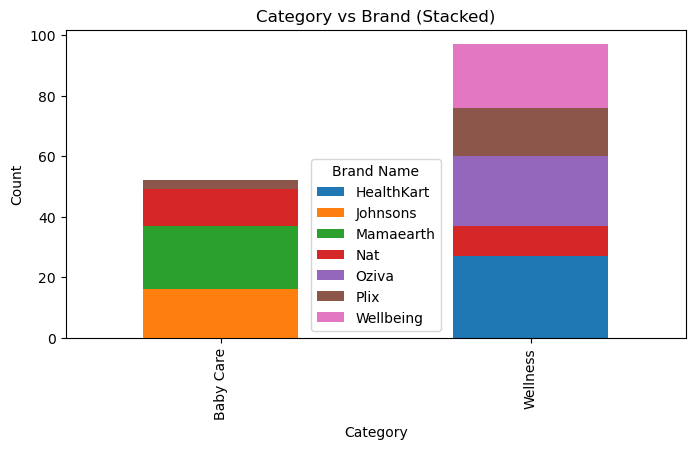

In [58]:
top_brands = df['Brand Name'].value_counts().head(7).index

pd.crosstab(
    df['Category'],
    df[df['Brand Name'].isin(top_brands)]['Brand Name']
).plot(kind='bar', stacked=True, figsize=(8,4))

plt.title('Category vs Brand (Stacked)')
plt.ylabel('Count')
plt.show()

#### Insights:
- The Wellness category has a higher number of products compared to Baby Care, showing stronger brand presence.

- Brands like Oziva, HealthKart, and Wellbeing dominate Wellness, indicating high competition in this category.

- Baby Care shows fewer products across brands, suggesting limited variety and lower market penetration.

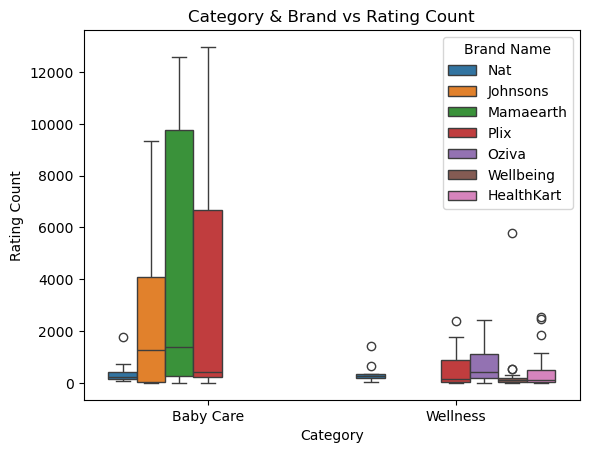

In [59]:
#Category & Brand vs Rating Count
sns.boxplot(
    x='Category',
    y='Rating Count',
    hue='Brand Name',
    data=df[df['Brand Name'].isin(top_brands)]
)
plt.title('Category & Brand vs Rating Count')
plt.show()

#### Insights:
- Baby Care category shows much higher rating counts than Wellness, indicating stronger customer engagement and popularity.
- Mamaearth and Plix lead in Baby Care, with the highest rating counts and wide variation, showing these brands are frequently purchased and reviewed.

- Wellness brands have lower and tightly clustered rating counts, suggesting limited customer interaction and comparatively lower demand.

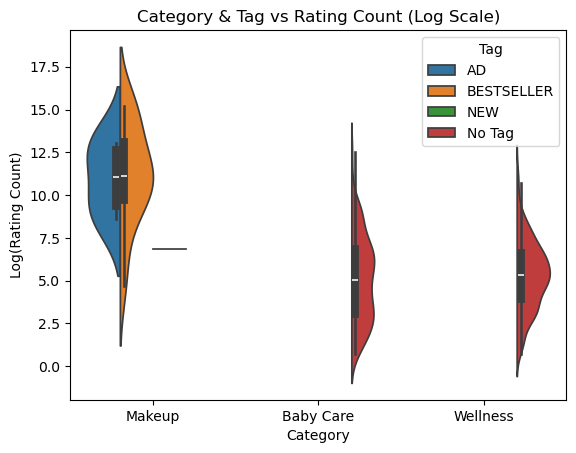

In [60]:
#Category & Tag vs Rating Count (Log Scale)
sns.violinplot(
    x='Category',
    y=np.log1p(df['Rating Count']),
    hue='Tag',
    data=df,
    split=True
)
plt.xlabel('Category')
plt.ylabel('Log(Rating Count)')
plt.title('Category & Tag vs Rating Count (Log Scale)')
plt.show()

#### Insights:
- Makeup products with AD and BESTSELLER tags show higher rating counts, indicating strong visibility and customer engagement.
- Baby Care and Wellness categories are mostly dominated by “No Tag” products, with comparatively lower rating counts than tagged Makeup products.
- Using a log scale highlights the wide variation in rating counts, showing that tagged products generally perform better than untagged ones

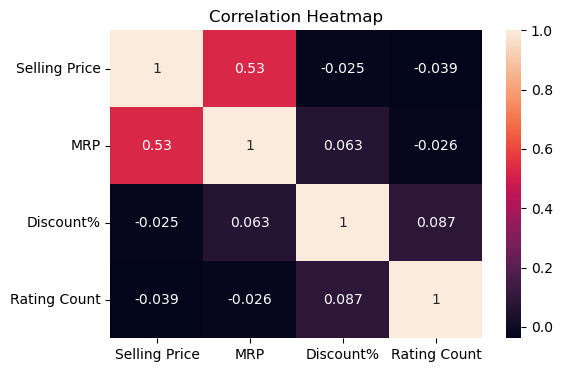

In [61]:
#Correlation Analysis of Price, Discount & Rating Count
corr = df[['Selling Price', 'MRP', 'Discount%', 'Rating Count']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()

#### Insights:
- Selling Price and MRP show a moderate positive correlation (0.53), meaning higher MRP products generally have higher selling prices.
- Discount percentage has very weak correlation with both price and rating count, indicating discounts do not strongly influence customer engagement.
- Rating Count shows almost no correlation with price or MRP, suggesting customer reviews are driven more by product value and popularity than pricing alone.

## Overall Conclusion

- Product data was successfully collected from the Nykaa website using web scraping techniques.
- The dataset required extensive cleaning due to request errors, duplicates, and inconsistent brand names.
- Exploratory Data Analysis helped identify patterns in pricing, discounts, and customer popularity.
- Rating Count proved to be an effective measure of customer engagement.
- Affordable and bestseller-tagged products received higher customer interaction.
- Price and discount percentage showed weak influence on customer popularity.
- Retaining outliers helped preserve real-world characteristics of premium and highly popular products.
